In [ ]:
%load_ext autoreload
%autoreload 2

In [96]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

from agg import build_all_channel_aggregates, compute_liquidity_signals
from notebook_shared import SharedNotebook


In [107]:
shd = SharedNotebook(algorithm=LGBMClassifier())
def wrangle(is_train: bool=True):
    df_to_use = pd.DataFrame()
    if is_train:
        shd.read_dataset("Train.csv", is_train=is_train)
        df_to_use = shd.train_df if shd.train_df is not None else pd.DataFrame()
    else:
        shd.read_dataset("Test.csv", is_train=is_train)
        df_to_use = shd.test_df if shd.test_df is not None else pd.DataFrame()

    # Month over month calculations
    running_df = shd.calculate_monthovermonth(["total_value", "highest_amount"])

    # Avg mom calculations (normally calculated inside the notebook)
    print("Avg mom calculations....")
    if df_to_use is not None:
        av_mom_df = shd.feature_pipeline.bal_avg_mom_calculations(df_to_use)
    else:
        raise ValueError("dataframe to use is None")

    running_df = pd.concat([running_df, av_mom_df], axis=1)

    # Removing autocorrelation features
    print("Removing autocorrelation features....")
    shd.remove_correlated_features(running_df)


    # Joining with the existing original dataset
    print("Aggregation, Liquidity signals andJoining with the existing original dataset....")
    train_df = pd.concat([df_to_use, running_df], axis=1)
    out = build_all_channel_aggregates(df_to_use)
    sig = compute_liquidity_signals(df_to_use, out)
    train_df = pd.concat([train_df, sig], axis=1)

    # If there is any numpy infite number raise exception
    if train_df.isin([np.inf, -np.inf]).any().sum():
        raise ValueError("There is any numpy infite number. Algorithm may fail to train.")

    # Remove features defined to be less useful
    print("Removing features defined to be less useful....")
    shd.define_features_to_remove(train_df)

    return train_df


In [75]:
running_df = wrangle()
running_df.head(2)


['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
['m1_paybill_highest_amount', 'm2_paybill_highest_amount', 'm3_paybill_highest_amount', 'm4_paybill_highest_amount', 'm5_paybill_highest_amount', 'm6_paybill_highest_amount', 'm1_merc

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,...,withdraw_share_of_outflow,paybill_share_of_outflow,total_outflow_value,total_inflow_value,outflow_to_inflow_ratio,outflow_channel_entropy,withdraw_active_months,paybill_active_months,withdraw_share_trend,paybill_share_trend
0,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,58372.55,5352.41,...,0.498137,0.325910,332489.28,590474.93,0.563088,1.106951,1,4,0.622915,-0.246824
1,2653.88,47,F,Central Zone,Yes,MVC,Monthly Earner,0.6905,0.00,0.00,...,0.732322,0.126699,884314.06,1286319.71,0.687476,0.838202,6,4,-0.205591,0.143456


In [109]:
from build import ModelPipeline
from sklearn.model_selection import train_test_split

def prepare_df(X, is_train=True):
    if not is_train:
        X_test, _ = shd.feature_pipeline.transform(X, is_train=is_train)
        X_test = X_test.loc[:, ~X_test.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_test, None)
        shd.remove_netflow_features(X_test, None)
        shd.find_and_remove_mom_features(X_test)
        return X_test
    else:
        raw_train, raw_val = train_test_split(
            X,
            test_size=0.2,
            stratify=X[shd.feature_pipeline.target_col],
            random_state=42,
        )

        X_train, y_train = shd.feature_pipeline.transform(raw_train)
        X_val, y_val = shd.feature_pipeline.transform(raw_val)
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

        if y_train is None:
            raise ValueError("y_train is None")
        
        pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

        # Get dulicated columns and remain with one of them
        X_train, X_val = X_train.loc[:, ~X_train.columns.duplicated()], X_val.loc[:, ~X_val.columns.duplicated()]
        shd.remove_features_definedby_algorithm_gain(X_train, X_val)
        shd.remove_netflow_features(X_train, X_val)
        shd.find_and_remove_mom_features(X_train)
        shd.find_and_remove_mom_features(X_val)

        return X_train, y_train, X_val, y_val, pos_weight

In [79]:
X_train, y_train, X_val, y_val, pos_weight = prepare_df(running_df)
X_train.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,inflow_slope_6m,outflow_slope_6m,bal_m1_m6_ratio,m1_cashout_intensity,avg_recent3_cashout,avg_old3_cashout,bal_std_dev_3m,bal_std_dev_6m,recent3_avg_balance,old3_avg_balance
16946,3187.16,38,0.4573,0.0,0.00,0.0,0.0,427.23,423.38,0.0,...,-787.396571,-90.661429,0.330573,0.000000,3364.713333,2847.010000,255.729161,613.381487,948.113333,1621.750000
39245,4769.99,45,0.5526,9075.4,7483.94,0.0,0.0,26574.00,1923.44,0.0,...,-7646.985143,30217.382000,1.348613,11.275563,199246.806667,46991.803333,1932.324033,2572.315753,10304.526667,6598.206667


In [80]:
model = shd.tune_lgbm(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Best Parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000, 'num_leaves': 15, 'reg_alpha': 10, 'reg_lambda': 20, 'scale_pos_weight': 2.8333333333333335}
Best CV Score: 0.8991


In [81]:
train_preds, val_preds = shd.run_predictions(model, X_train, X_val, y_train, y_val)


Train ROC:  0.9759719362745098
Val ROC:  0.8942272058823529
Val Log Loss:  0.28871048981772096


Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      6800
           1       0.58      0.64      0.61      1200

    accuracy                           0.88      8000
   macro avg       0.76      0.78      0.77      8000
weighted avg       0.88      0.88      0.88      8000



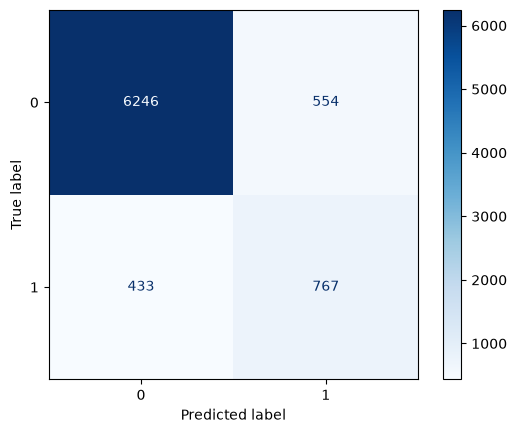

In [82]:
shd.build_cm(y_val, val_preds)

In [83]:
clb_model = shd.calibrate_model(model, X_train, y_train)
val_pred = shd.run_calibrated_predictions(clb_model, X_val)
val_pred

array([0.00869951, 0.06999349, 0.75492415, ..., 0.00309922, 0.0045118 ,
       0.11270173], shape=(8000,))

In [85]:
shd.display_val_prediction_stats(val_pred, y_val)

Val ROC:  0.8944926470588234
Val Log Loss:  0.26572430555966015


In [108]:
# Do the same process for test dataframe
shd = SharedNotebook(algorithm=LGBMClassifier(), is_train=False)
test_running_df = wrangle(is_train=False)
test_running_df.shape

Reaing test dataset
Is self.test available:  True
Is it training mode:  False
['m1_paybill_total_value', 'm2_paybill_total_value', 'm3_paybill_total_value', 'm4_paybill_total_value', 'm5_paybill_total_value', 'm6_paybill_total_value', 'm1_merchantpay_total_value', 'm2_merchantpay_total_value', 'm3_merchantpay_total_value', 'm4_merchantpay_total_value', 'm5_merchantpay_total_value', 'm6_merchantpay_total_value', 'm1_received_total_value', 'm2_received_total_value', 'm3_received_total_value', 'm4_received_total_value', 'm5_received_total_value', 'm6_received_total_value', 'm1_deposit_total_value', 'm2_deposit_total_value', 'm3_deposit_total_value', 'm4_deposit_total_value', 'm5_deposit_total_value', 'm6_deposit_total_value', 'm1_withdraw_total_value', 'm2_withdraw_total_value', 'm3_withdraw_total_value', 'm4_withdraw_total_value', 'm5_withdraw_total_value', 'm6_withdraw_total_value']
Is self.test available:  True
Is it training mode:  False
['m1_paybill_highest_amount', 'm2_paybill_highe

(30000, 182)

In [111]:
X_test = prepare_df(test_running_df, is_train=False)
X_test.head(2)

,arpu,age,x_90_d_activity_rate,m1_paybill_total_value,m1_paybill_highest_amount,m2_paybill_total_value,m2_paybill_highest_amount,m3_paybill_total_value,m3_paybill_highest_amount,m4_paybill_total_value,...,inflow_slope_6m,outflow_slope_6m,bal_m1_m6_ratio,m1_cashout_intensity,avg_recent3_cashout,avg_old3_cashout,bal_std_dev_3m,bal_std_dev_6m,recent3_avg_balance,old3_avg_balance
0,2653.88,47,0.6905,0.00,0.00,0.0,0.0,21341.77,5938.05,7831.85,...,-14924.674286,1727.573714,0.441833,7.900611,61776.256667,63108.470000,5251.054242,3923.410588,11300.963333,13561.640000
1,2653.88,47,0.6905,89420.67,4231.17,0.0,0.0,0.00,0.00,19568.77,...,-37334.222000,13836.636286,1.916536,14.195614,207724.480000,147963.236667,3572.332030,3437.153505,7060.723333,6922.753333


In [112]:
test_pred = shd.run_calibrated_predictions(clb_model, X_test)

In [115]:
shd.save_submission_file(test_running_df, test_pred)

Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.017364
1,ID_29975A9C7E,0.047352
2,ID_F59CE25650,0.011864
3,ID_E875F68D1A,0.000736
4,ID_2902B1C0D0,0.007180
...,...,...
29995,ID_3C7CF79AEE,0.006857
29996,ID_F1651E73C4,0.008814
29997,ID_FD3F0934CA,0.179146
29998,ID_DA6916D6C7,0.007247
